In [1]:
import numpy as np
from matplotlib import pyplot as plt
import nibabel as nb
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt
from glob import glob
import tifffile as tiff
import sys
import os
from glob import glob
sys.path.append('../')

# from slice_structure_identification_functions import compute_signed_distance_weight as compute_signed_distance_weight
# from slice_structure_identification_functions import compute_signed_distance_weight_filled as compute_signed_distance_weight_filled
from slice_registration_functions import apply_coordinate_mapping_2d, downsample_image

zefir_0000__Image_01_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0001__Image_01_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0002__Image_02_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0003__Image_02_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0004__Image_03_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0005__Image_03_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0006__Image_04_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0007__Image_04_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0008__Image_05_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0009__Image_05_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0010__Image_06_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0011__Image_06_-_20x_02_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0012__Image_07_-_20x_01_cellCount_29_downsample_10p002um_pix.nii.gz
zefir_0013__Image_07_-_20x_02_cellCoun

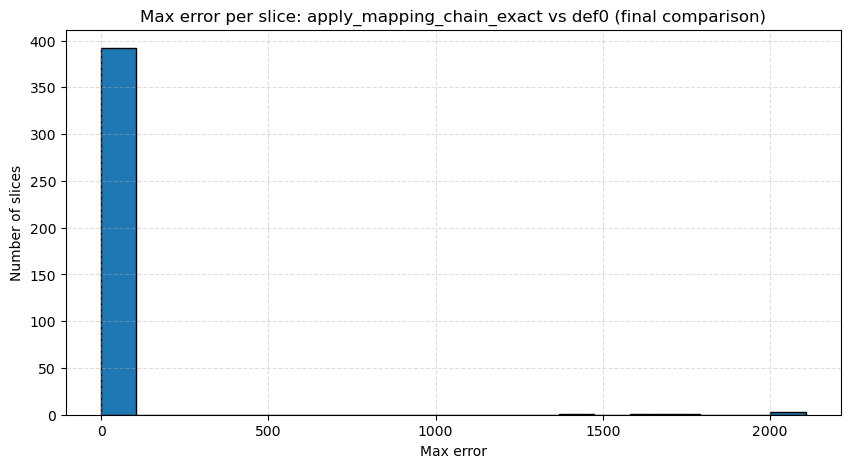

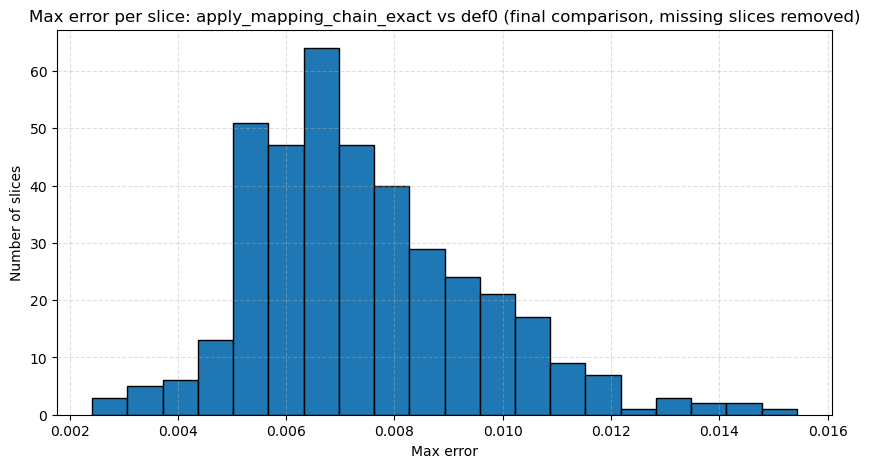

In [2]:
root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'
# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
for name_idx, orig_fname in enumerate(orig_fnames):
    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]

    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    # comp_exact = apply_mapping_chain_exact(src, [m1_, m2_, m3_, m4_, m5_, m6_, m7_, m8_, m9_]).get_fdata()

    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

plt.figure(figsize=(10, 5))
plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

plt.xlabel('Max error')
plt.ylabel('Number of slices')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()




In [5]:
slice_pathroot_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_40'

# root_dir = '/tmp/zefir_sliceReg_optimized_v2_rescale_50/'


label_dir = '/data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/'

# Generate list of slice directories by globbing based on unique numeric prefix (zefir_XXXX_...)
# `glob` may be a function from previous imports, so call it directly.
orig_fnames = sorted(glob(os.path.join(root_dir, 'zefir_????_*_pix.nii.gz')))

max_errors = []
missing_slices = []
bad_slices = [] #exceed max_error_thresh
max_error_thresh = 5.0
final_space_labels = {}
final_space_labels['img'] =[]
final_space_labels['fname_header'] =[]
final_space_labels['final_reg_space_def0'] = []
for name_idx, orig_fname in enumerate(orig_fnames):
    
    # labeled_maskos.path.basename(PC_files[0].split('_mask_')[0])
    # labeled_mask 

    slice_name = os.path.basename(orig_fname)
    base_slice = slice_name.split('_downsample_10p002um_pix')[0]
    fname_header = base_slice.split('__')[0]
    labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
    if len(labeled_mask) == 0:
        # print(f"No labeled mask found for {slice_name}")
        continue
    elif len(labeled_mask) > 1:
        # print(f"Multiple labeled masks found for {slice_name}: {labeled_mask}")
        continue        
    
        
    labeled_mask_fname = labeled_mask[0]
    if os.path.exists(labeled_mask_fname):
        print(f"Found labeled mask for {slice_name}: {labeled_mask_fname}")
    
    labeled_mask = tiff.imread(labeled_mask_fname).astype(bool).astype(np.uint8) # read and convert to bin
    _ds_label_cnt = downsample_image(labeled_mask, 40, pad_value=-1*0) #now counts per pixel
    
    



    source_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix.nii.gz")
    mapping_img = os.path.join(root_dir, f"init_translation_slice_{base_slice.split('_')[1]}/{base_slice}_downsample_10p002um_pix_coreg0nl_ants-map.nii.gz")
    mapping_img3 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_ants-map.nii.gz")
    mapping_img4 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-map.nii.gz")
    mapping_img5 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter4_ants-map.nii.gz")
    mapping_img6 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter5_ants-map.nii.gz")
    mapping_img7 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter6_ants-map.nii.gz")
    mapping_img8 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter7_ants-map.nii.gz")
    mapping_img9 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter8_ants-map.nii.gz")
    mapping_img10 = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-map.nii.gz")
    
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter3_ants-def0.nii.gz")
    final_comparison_img = os.path.join(root_dir, f"{base_slice}_downsample_10p002um_pix_coreg12nl_win12_rigsyn_4_groupwise_iter9_ants-def0.nii.gz")

    if not (os.path.exists(source_img) and os.path.exists(mapping_img) and os.path.exists(mapping_img3) and os.path.exists(mapping_img4)):
        missing_slices.append(slice_name)
        continue
    print(slice_name)
    src = nb.load(source_img)
    m1_ = nb.load(mapping_img)
    m2_ = nb.load(mapping_img3)
    m3_ = nb.load(mapping_img4)
    m4_ = nb.load(mapping_img5)
    m5_ = nb.load(mapping_img6)
    m6_ = nb.load(mapping_img7)
    m7_ = nb.load(mapping_img8)
    m8_ = nb.load(mapping_img9)
    m9_ = nb.load(mapping_img10)
    
    label_cnt_img = nb.Nifti1Image(_ds_label_cnt, affine=src.affine, header=src.header)

    comparison = nb.load(final_comparison_img).get_fdata()
    # seq = apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(apply_coordinate_mapping_2d(src, m1_), m2_), m3_).get_fdata()
    seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        src, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_).get_fdata()
    labeled_seq = apply_coordinate_mapping_2d(
        apply_coordinate_mapping_2d(
            apply_coordinate_mapping_2d(
                apply_coordinate_mapping_2d(
                    apply_coordinate_mapping_2d(
                        apply_coordinate_mapping_2d(
                            apply_coordinate_mapping_2d(
                                apply_coordinate_mapping_2d(
                                    apply_coordinate_mapping_2d(
                                        label_cnt_img, m1_), m2_), m3_), m4_), m5_), m6_), m7_), m8_), m9_)

    final_space_labels['img'].append(labeled_seq)
    final_space_labels['fname_header'].append(fname_header)
    final_space_labels['final_reg_space_def0'].append(nb.load(final_comparison_img))
    break
    max_err = np.abs(seq -comparison).max()
    max_errors.append(max_err)
    if max_err > max_error_thresh:
        bad_slices.append((slice_name, max_err, name_idx))

max_errors = np.array(max_errors)
print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

print(f"Processed {len(max_errors)} slices successfully.")
if missing_slices:
    print(f"Skipped {len(missing_slices)} slices due to missing files: {missing_slices[:10]}{'...' if len(missing_slices) > 10 else ''}")

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors, bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison)')
# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.hist(max_errors[max_errors<max_error_thresh], bins=20, color='tab:blue', edgecolor='black')
# plt.title('Max error per slice: apply_mapping_chain_exact vs def0 (final comparison, missing slices removed)')

# plt.xlabel('Max error')
# plt.ylabel('Number of slices')
# plt.grid(True, linestyle='--', alpha=0.4)
# plt.show()




Found labeled mask for zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz: /data/neuralabc/johmat/phase_ml/processing/full_slide_masks/2025_01_01/zefir_0116__Image_03_-_20x_mask.ome.tif
zefir_0116__Image_04_-_20x_cellCount_29_downsample_10p002um_pix.nii.gz
Processed 0 slices successfully.
Processed 0 slices successfully.


In [6]:
labeled_mask = glob(os.path.join(label_dir, f"{fname_header}_*_mask*.tif"))
labeled_mask_fname = labeled_mask[0]
labeled_mask = tiff.imread(labeled_mask_fname)
labeled_mask = labeled_mask.astype(bool).astype(np.uint8) #convert to binary mask
_ds = downsample_image(labeled_mask, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)

orig_cell_counts_fname = '/data/neuralabc/neuralabc_volunteers/macaque/testProject2/results_cell_counts/_Image_03_-_20x_cellCount_29_downsample_10p002um_pix.tif'
orig_cell_counts = tiff.imread(orig_cell_counts_fname)



In [7]:
_ds1 = downsample_image(labeled_mask, 29, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)
_ds2 = downsample_image(_ds1, 40, pad_value=-1*0) #this sets the pad value to be a negative value outside of the range of the data, which is important for the SDF computation later, since we want to make sure that the padding does not create artificial boundaries that will impact the SDF computation (since it will create a boundary between the data and the padding)



In [278]:
target_shape = orig_cell_counts.shape
current_shape = labeled_mask.shape
scale_factors = 1/(np.array(target_shape) / np.array(current_shape))

print(f"Target shape: {target_shape}")
print(f"Current shape: {current_shape}")
print(f"Scale factors: {scale_factors}")


Target shape: (2178, 2622)
Current shape: (63158, 76025)
Scale factors: [28.99816345 28.99504195]
